In [1]:
try:
    from google.colab import drive
    drive.mount('/gdrive')
    dataset_root = '/gdrive/MyDrive/datasets'
    !pip install torchinfo tqdm
    colab = True
except Exception as e:
    print(e)
    print('Assuming we\'re not on colab.')
    dataset_root = './datasets'
    colab = False

print('Will store datasets in', dataset_root)

import os

if os.name == 'nt':
    print("Disabling multiprocessing because we're running on windows.")
    cpu_num = 0
elif colab:
    cpu_num = 2
else:
    cpu_num = os.cpu_count() // 2
    print('Dataloaders will use {} CPUs'.format(cpu_num))

No module named 'google'
Assuming we're not on colab.
Will store datasets in ./datasets
Dataloaders will use 8 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# 20 classes, as well as none.
classes = {
    0:'None',
    1:'Aeroplane',
    2:'Bicycle',
    3:'Bird',
    4:'Boat',
    5:'Bottle',
    6:'Bus',
    7:'Car',
    8:'Cat',
    9:'Chair',
    10:'Cow',
    11:'Diningtable',
    12:'Dog',
    13:'Horse',
    14:'Motorbike',
    15:'Person',
    16:'Pottedplant',
    17:'Sheep',
    18:'Sofa',
    19:'Train',
    20:'Tvmonitor',
}
# num_classes = len(classes)
num_classes = 2

In [11]:
# 500x500 is the max width and height in voc. Images may not be square,
# but are always equal to or smaller than 500x500.
# We use 512 since it's a nice power of 2.
nn_dim = (500,500)
train_tfs_v2 = tv2.Compose([
    tv2.ToImage(),
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomResizedCrop(nn_dim, antialias=True),
    tv2.SanitizeBoundingBoxes(),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    tv2.ConvertBoundingBoxFormat('XYXY')
])

val_tfs_v2 = tv2.Compose([
    tv2.ToImage(),
    tv2.Resize(nn_dim),
    tv2.SanitizeBoundingBoxes(),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    tv2.ConvertBoundingBoxFormat('XYXY')
])

coco_train = tds.CocoDetection(
    root=dataset_root + '/coco128/images',
    annFile=dataset_root + '/coco128/labels/train2017',
    transforms=train_tfs_v2
)
coco_train = tds.wrap_dataset_for_transforms_v2(voc_train)

# voc_val = tds.VOCDetection(
#     root=dataset_root,
#     download=True,
#     year='2012',
#     image_set='val',
#     transforms=val_tfs_v2
# )
# voc_val = tds.wrap_dataset_for_transforms_v2(voc_val)

loading annotations into memory...


IsADirectoryError: [Errno 21] Is a directory: './datasets/coco128/labels/train2017'

In [5]:
voc_train[1]

(Image([[[-1.4843, -1.4843, -1.5185,  ..., -1.6898, -1.6727, -1.6727],
         [-1.4843, -1.4843, -1.5185,  ..., -1.6898, -1.6727, -1.6727],
         [-1.4672, -1.4672, -1.5014,  ..., -1.6727, -1.6555, -1.6555],
         ...,
         [-0.9363, -0.9363, -0.9705,  ..., -0.6965, -0.7137, -0.7137],
         [-0.8507, -0.8507, -0.8849,  ..., -0.6281, -0.6281, -0.6281],
         [-0.8507, -0.8507, -0.8849,  ..., -0.6281, -0.6281, -0.6281]],
 
        [[-1.5455, -1.5455, -1.5805,  ..., -1.5980, -1.5805, -1.5805],
         [-1.5455, -1.5455, -1.5805,  ..., -1.5980, -1.5805, -1.5805],
         [-1.5105, -1.5105, -1.5455,  ..., -1.6155, -1.6155, -1.6155],
         ...,
         [-1.5805, -1.5805, -1.6155,  ..., -1.5455, -1.5455, -1.5455],
         [-1.5105, -1.5105, -1.5455,  ..., -1.5280, -1.5105, -1.5105],
         [-1.5105, -1.5105, -1.5455,  ..., -1.5280, -1.5105, -1.5105]],
 
        [[-1.2293, -1.2293, -1.2467,  ..., -1.1596, -1.1421, -1.1421],
         [-1.2293, -1.2293, -1.2467,  ..., 

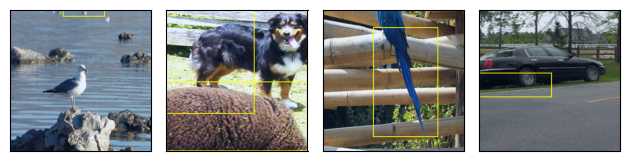

In [8]:
from helpers import plot
ix = 20
samples = []
for x in range(4):
    i, b = voc_train[ix + x][0], voc_train[ix + x][1]['boxes']
    samples.append((i, b))
    
plot(samples)

/home/kyle/micromamba/envs/ml/lib/python3.10/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


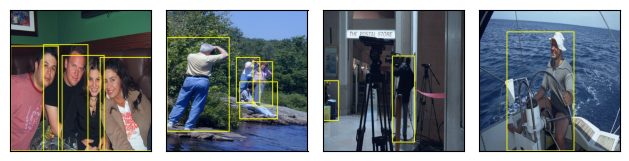

In [7]:
ix = 400
samples = []
for x in range(4):
    i, b = voc_val[ix + x][0], voc_val[ix + x][1]['boxes']
    samples.append((i, b))
plot(samples)